# Chromatin PTR analysis
February 32, 2024

Update PTR analysis of latest chromatin deconvolution results. Higher resolution chromatin results. Goal is to summarize a gene's cycling chromatin with a top k values of cycling chromatin.

Possibly sweep for what k values can be reasonable. Maybe think through how we can sweep for an appropriate k.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [147]:
import glob

outdir = 'output/deconvolve_combined_g006_2024_03_08_dg1_fix/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


In [149]:
from src.timer import Timer

timer = Timer()

peak_to_trough_analysis.load_ptr_files()
peak_to_trough_analysis.sort_gene_ptrs()
peak_to_trough_analysis.compute_gene_ptr_rank_per_k()

timer.get_time()


'00:00:02.76'

## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [153]:
mean = peak_to_trough_analysis.summarize_ptrs(np.mean)
median = peak_to_trough_analysis.summarize_ptrs(np.median)
q95 = peak_to_trough_analysis.compute_q_vals(0.95)

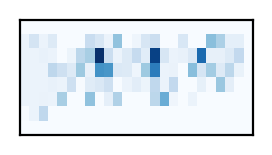

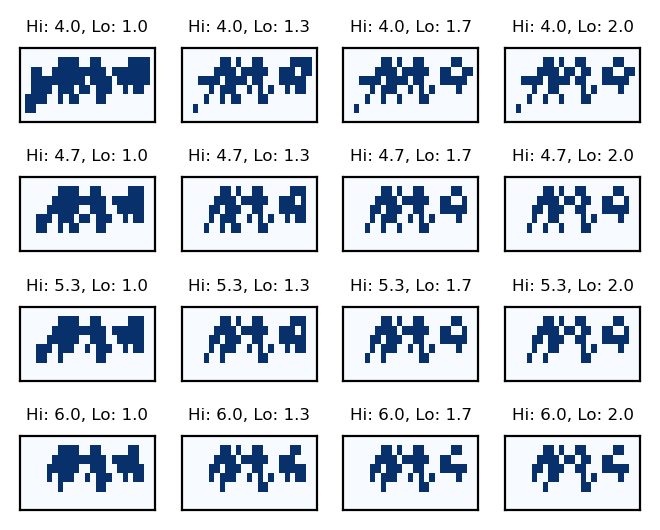

In [154]:
plotter.plot_threshold_scan('CLB2')

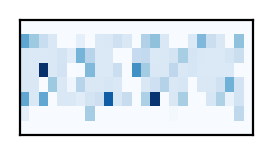

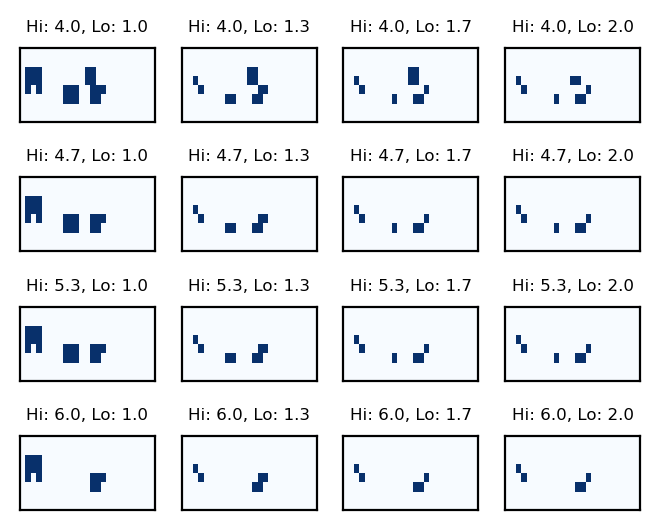

In [187]:
plotter.plot_threshold_scan('FIG1')

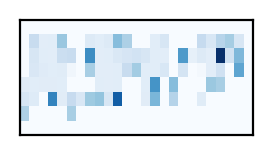

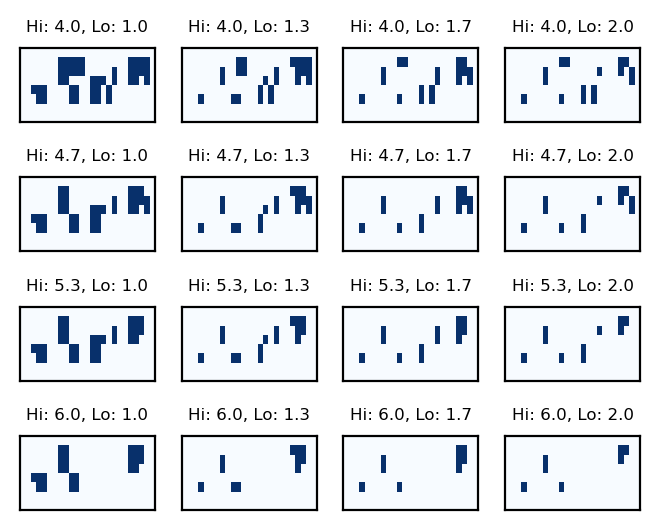

In [188]:
plotter.plot_threshold_scan('PCL1')

In [208]:
peak_to_trough_analysis.ptr_imgs.shape

(5578, 8, 25)

In [213]:
prom_size = 288
bin_width = 32

p1_loc = prom_size
p1_padding = 40

p1_loc_span = p1_loc-p1_padding, p1_loc+p1_padding
p1_loc_span_bins = p1_loc_span[0]//bin_width, p1_loc_span[1]//bin_width

p1_loc_span_bins

# Let's find the ptrs with the most cycling +1 locations

cycling_p1s = peak_to_trough_analysis.ptr_imgs[:, :, p1_loc_span_bins[0]:p1_loc_span_bins[1]]
cycling_p1s.shape

(5578, 8, 3)

In [221]:
mean_p1 = cycling_p1s.mean(axis=1).mean(axis=1)

In [228]:
mean_p1_df = peak_to_trough_analysis.undropped_ptrs_df[[]].copy()
mean_p1_df['mean_p1'] = mean_p1
mean_p1_df.head(2)

,mean_p1
orf_name,
YAL067W-A,0.57112
YAL067C,0.916323


In [229]:
from src.ptr_analysis_plotter import PTRAnalysisPlotter

plotter = PTRAnalysisPlotter(peak_to_trough_analysis, mean_p1_df['mean_p1'])
plotter.set_quantiles(np.linspace(1.0, .0, 11))
#plotter.plot_distribution()

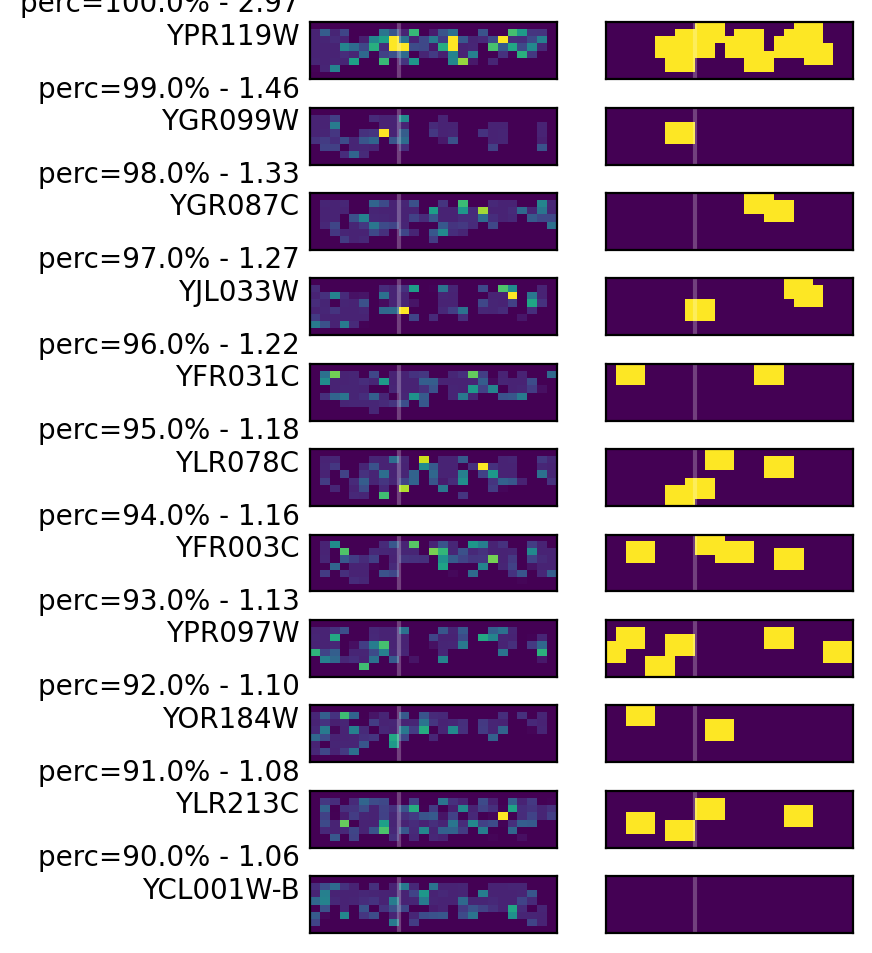

In [233]:
plotter.plot_metric_examples_quantiles(low=0, hi=6)

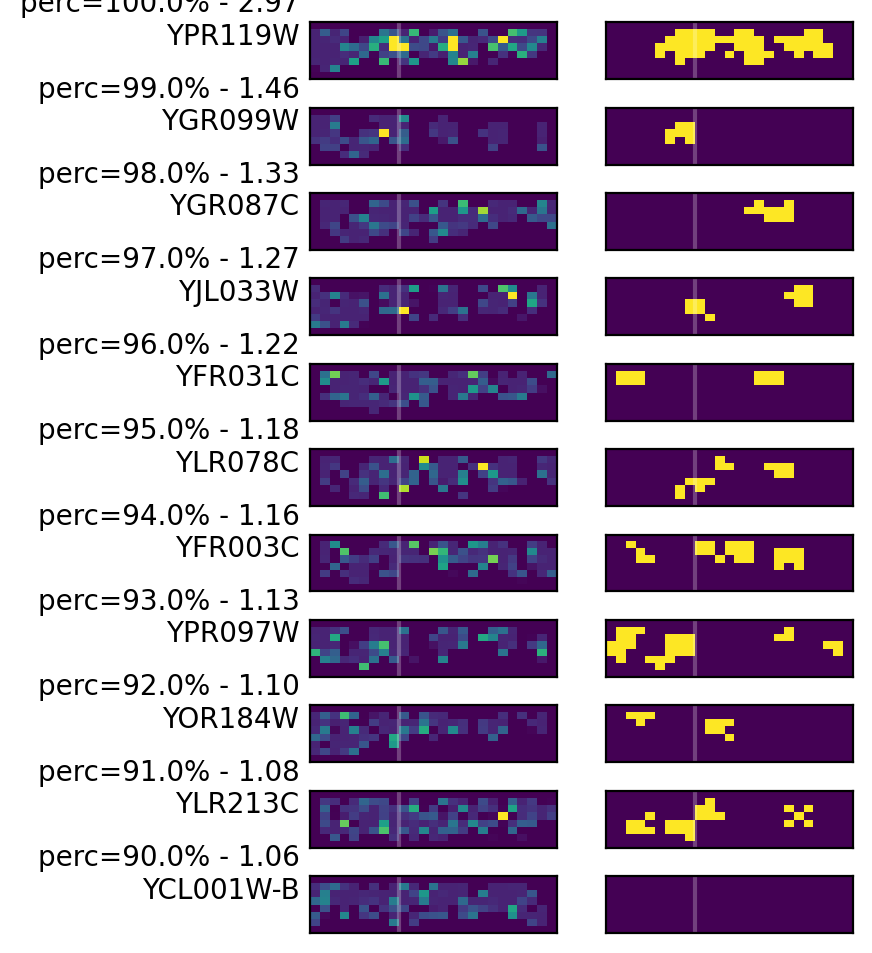

In [231]:
plotter.set_quantiles(np.linspace(1.0, 0.9, 11))
plotter.plot_metric_examples_quantiles(low=1, hi=6)